In [1]:
import sys
import os
project_root = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append(str(project_root))

In [2]:
import os
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset as HFDataset
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.visualization import plot_label_distributions
import seaborn as sns
from configs.config_loader import load_datasets_config, load_federated_config

/Users/mustafaaktas/anaconda3/envs/Federated-Learning-Comparative-Study/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATASET = "hcdr"

dataset_config = load_datasets_config()[DATASET]
federated_config = load_federated_config()["ml_pipeline_experiments"]

label_name = dataset_config["target"]

CURRENT_FILE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))

data_path = str(os.path.join(CURRENT_FILE_DIR, dataset_config["path"]))
df = pd.read_csv(data_path)

In [4]:
df.shape

(307511, 225)

/var/folders/w2/h_x3xv0d2616hcyyqp9k7yjh0000gn/T/ipykernel_13678/210066030.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


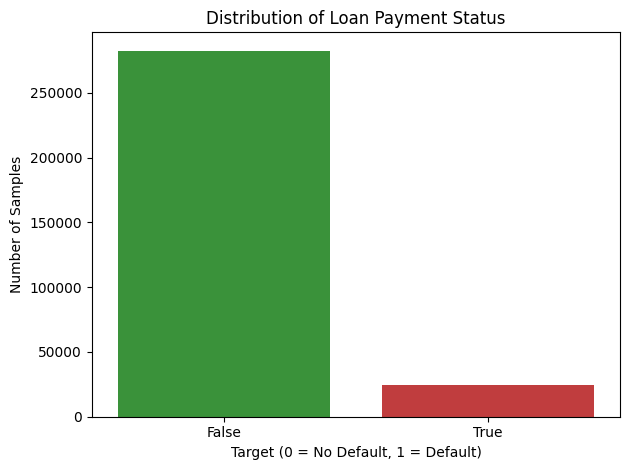

In [6]:
target_col = 'TARGET'
counts = df[target_col].value_counts().reset_index()
counts.columns = [target_col, 'count']

# Plot
sns.barplot(
    data=counts,
    x=target_col,
    y='count',
    palette=['#2ca02c', '#d62728']  # green for 0, red for 1
)
plt.xlabel('Target (0 = No Default, 1 = Default)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Loan Payment Status')
plt.xticks([0, 1])
plt.tight_layout()

plt.savefig("default_graph_hcdr.png")

plt.show()

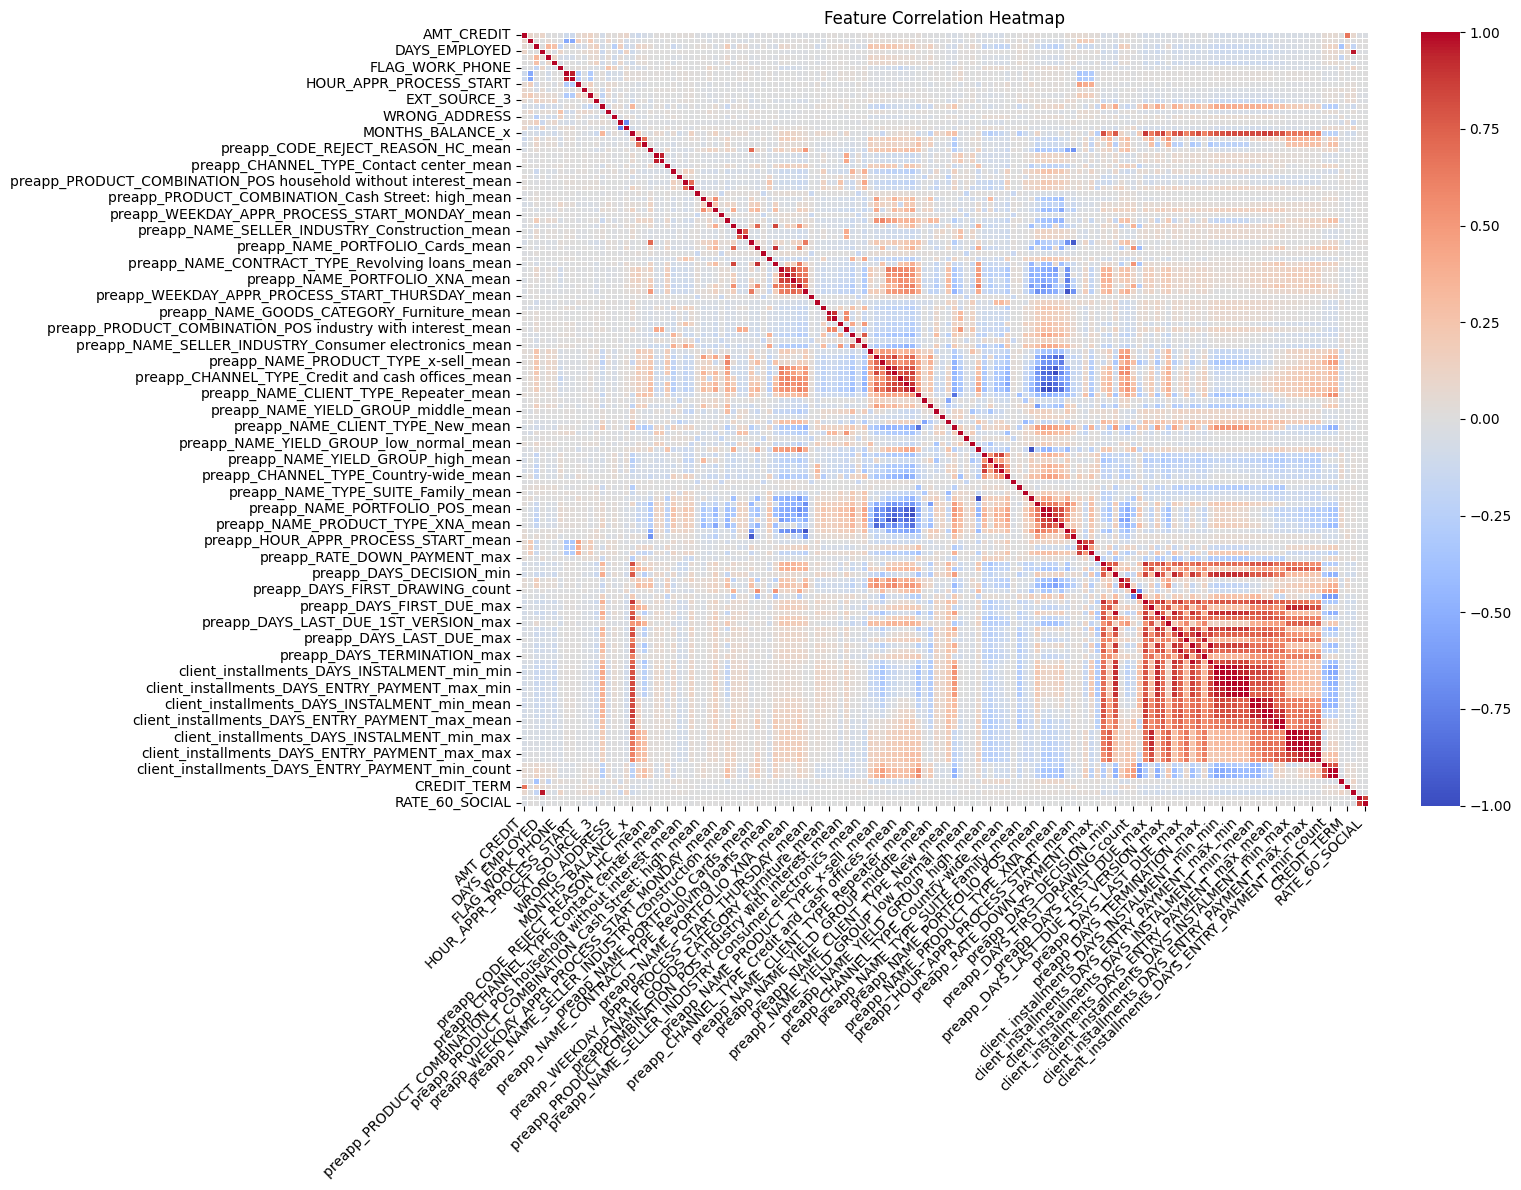

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df = numeric_df.drop("SK_ID_CURR", axis=1)
# Compute correlation matrix on numeric data only
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    center=0,
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"heatmap_hcdr.png")
plt.show()